## Tarea M26-CD- YAIR PALOMARES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:

data = pd.read_csv("Amazon.csv")
data

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43
...,...,...,...,...,...,...,...,...,...,...
95,Teofan,3,8,32,25,7,21,42,17,1
96,Teofil,305,25,46,24,33,28,355,26,45
97,Teofila,1,14,26,25,24,27,42,185,23
98,Teon,155,11,335,34,26,29,42,215,27


In [4]:
#Normalizar los datos porque las escalas si están muy diferentes
from sklearn.preprocessing import normalize
data_scaled = data.drop("Unnamed: 0", axis=1)
data_scaled = normalize(data_scaled)
#Hacemos el arreglo normalizado un data frame
columns_name = list(data.columns)
columns_name.pop(0)
data_scaled = pd.DataFrame(data_scaled, columns = columns_name)

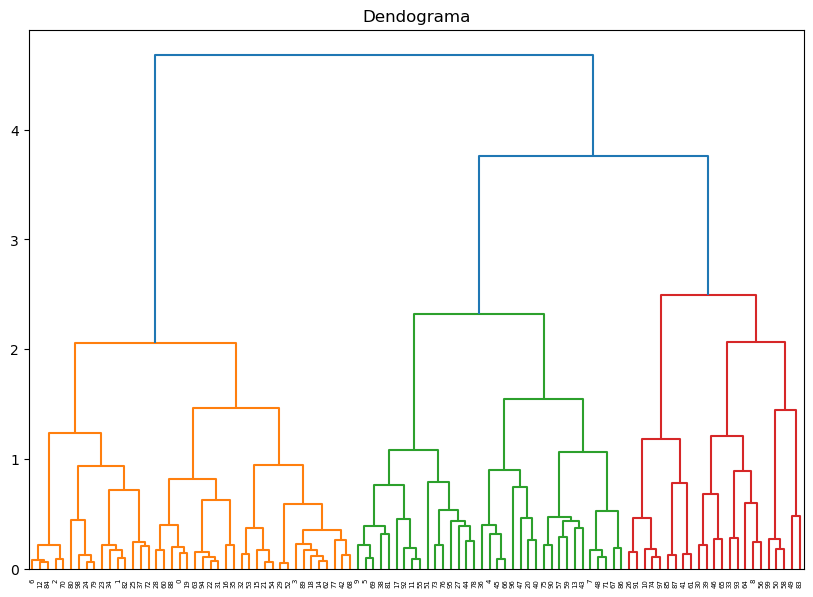

In [5]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10,7))
plt.title("Dendograma")
dend = shc.dendrogram(shc.linkage(data_scaled, method="ward"))

In [6]:
colores_unicos = set(dend["color_list"])
colores_unicos

{'C0', 'C1', 'C2', 'C3'}

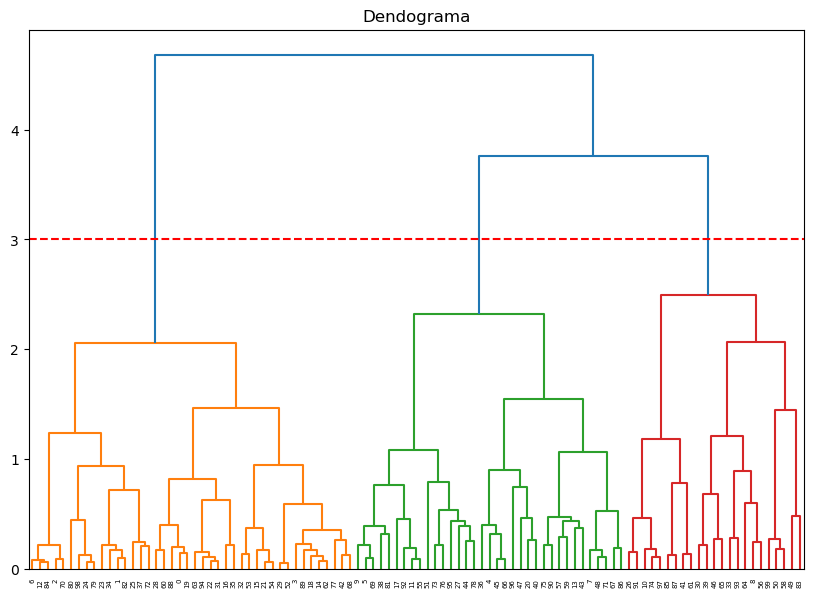

In [7]:
#Se agrega una linea horizontal donde está el valor de los clustering óptimos
plt.figure(figsize=(10,7))
plt.title("Dendograma")
dend = shc.dendrogram(shc.linkage(data_scaled, method="ward"))
plt.axhline(y=3, color="r", linestyle="--")

In [8]:
#Se etiqueta a cada dato con su grupo asignado
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=3, affinity="euclidean", linkage="ward")
grupos = cluster.fit_predict(data_scaled)
grupos

D:\Anaconda\Lib\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


array([1, 1, 1, 1, 2, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 0,
       2, 2, 1, 2, 1, 2, 1, 2, 0, 2, 2, 1, 2, 1, 1, 2, 1, 0, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 0, 1, 2, 2, 0, 1, 0], dtype=int64)

In [9]:
#Separación de grupos mediante PCA
campos = data_scaled.values
from sklearn import decomposition
pca = decomposition.PCA(n_components=2)
pca.fit(campos)
campos = pca.transform(campos)
campos

array([[-0.39993219,  0.06035374],
       [-0.40829583, -0.06402268],
       [-0.49703182, -0.35955286],
       [-0.33996675,  0.18434501],
       [ 0.58207751, -0.38797653],
       [ 0.1723403 , -0.52962573],
       [-0.56528441, -0.33770585],
       [ 0.5335887 ,  0.06994712],
       [ 0.09981604,  0.47165743],
       [ 0.22195207, -0.56503313],
       [ 0.08274005,  0.39712712],
       [-0.00143465, -0.48936583],
       [-0.57292039, -0.35927774],
       [ 0.51350639,  0.01301312],
       [-0.35272162,  0.20639728],
       [-0.4688626 ,  0.0168001 ],
       [-0.25142488,  0.04599019],
       [-0.05456876, -0.22302796],
       [-0.36123131,  0.20553368],
       [-0.41087067,  0.02173183],
       [ 0.54207892, -0.03308916],
       [-0.5138909 , -0.0900875 ],
       [-0.4284552 , -0.0601418 ],
       [-0.42320562, -0.09945498],
       [-0.42610215,  0.06318626],
       [-0.10615885, -0.20376697],
       [ 0.19058214,  0.3966612 ],
       [-0.096838  , -0.33104612],
       [-0.51505714,

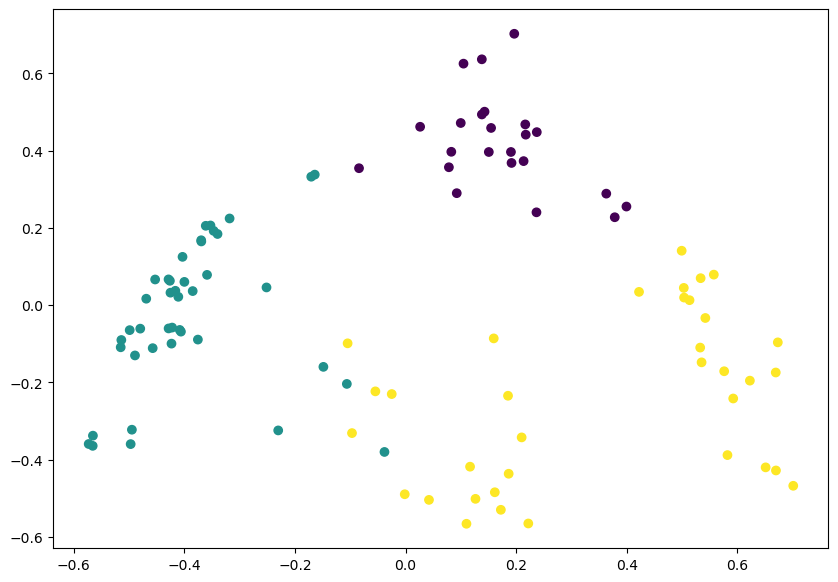

In [10]:
#Se grafican los datos ya con PCA
plt.figure(figsize=(10,7))
plt.scatter(campos[:,0], campos[:,1], c=cluster.labels_)

In [11]:
#Convertimos la clasificación de los datos a un dataframe
dataframe = pd.DataFrame(grupos, columns = ["grupo"])
#Se unen los dos dataframe para visualizar en la base de datos a que grupo pertenece cada observación
dataframe2 = pd.concat([data, dataframe], axis=1, join="inner")
dataframe2

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
0,Adam,205,3,345,235,24,23,26,21,17,1
1,Anna,9,15,315,33,25,4,42,215,28,1
2,Bernard,17,26,285,3,43,27,41,26,33,1
3,Edward,135,5,355,295,18,23,39,195,17,1
4,Emilia,3,45,48,39,34,46,225,34,43,2
...,...,...,...,...,...,...,...,...,...,...,...
95,Teofan,3,8,32,25,7,21,42,17,1,2
96,Teofil,305,25,46,24,33,28,355,26,45,2
97,Teofila,1,14,26,25,24,27,42,185,23,0
98,Teon,155,11,335,34,26,29,42,215,27,1


In [12]:
#Para conclusiones de la práctica
recomendaciones = dataframe2[dataframe2["Unnamed: 0"].isin(["Salome", "Stephania", "Lydia"])]
recomendaciones

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
54,Lydia,19,4,435,145,16,21,28,185,24,1
81,Salome,17,23,275,41,4,44,315,28,32,2
89,Stephania,215,125,465,315,34,4,37,305,45,1


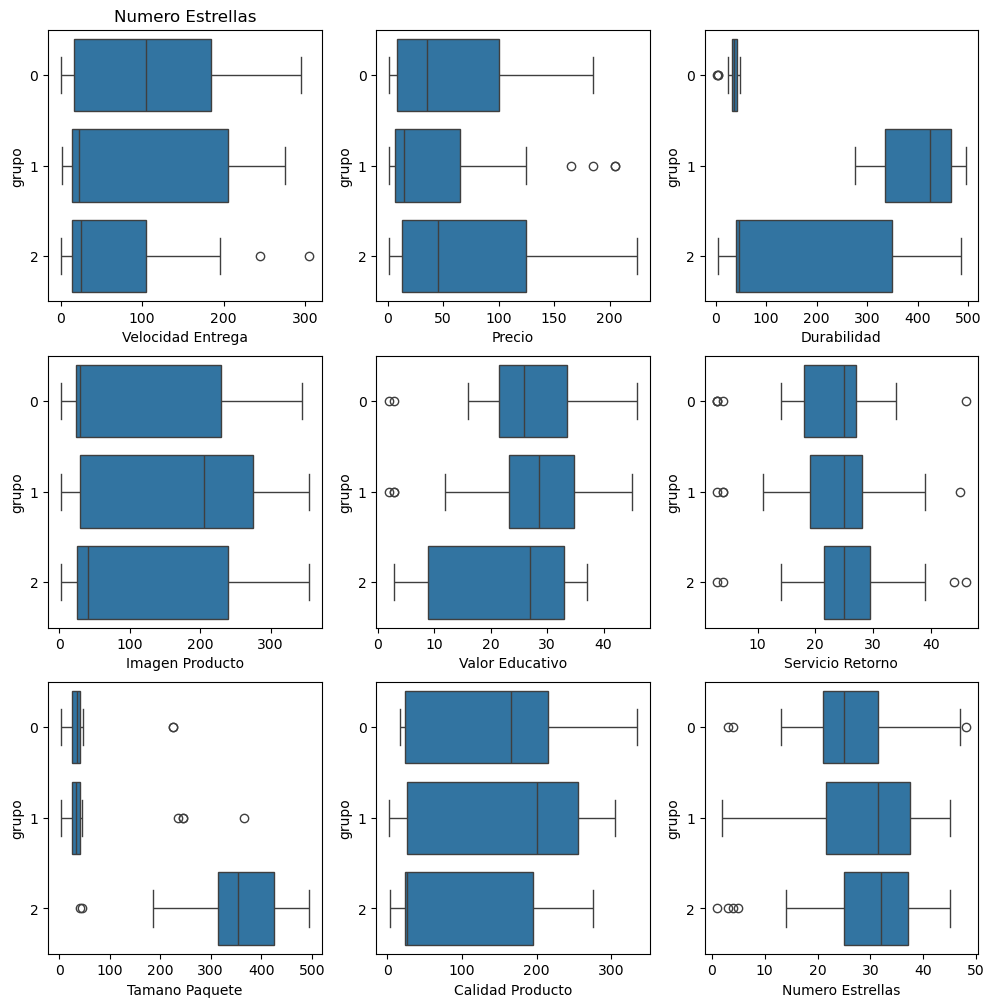

In [34]:
import seaborn as sns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
dataframe2["grupo"] = dataframe2["grupo"].astype("category")
columnas_name = list(dataframe2.columns)
columnas_name.remove("Unnamed: 0")
columnas_name.remove("grupo")
cont = 0
for i in range(3):
    for j in range(3):
        sns.boxplot(data=dataframe2, x=columnas_name[cont], y="grupo", ax = axes[i,j])
        axes[0, 0].set_title(columnas_name[cont])
        cont = cont + 1
plt.show()

In [39]:
# ¿Qué productos recomendarías a Salomé?
recomendaciones_enfoque_salome = dataframe2[dataframe2["grupo"] == 2]
print("Salomé pertenece al grupo 2, por lo tanto recomendaría los tipos de productos que frecuentan personas como:\n", recomendaciones_enfoque_salome["Unnamed: 0"].values)
print()
print("De acuerdo con los datos, el grupo 2 suele consumir productos de un mayor tamaño aunque tengan un mayor precio. Así como también no dan tanta importancia al valor educativo, velocidad de entrega, ni durabilidad.")

Salomé pertenece al grupo 2, por lo tanto recomendaría los tipos de productos que frecuentan personas como:
 ['Emilia' 'Fabian' 'Frank' 'Gabriel' 'Henry' 'Isabelle' 'Eugenia'
 'Evdokia' 'Florence' 'Jeremiah' 'Joachim' 'Santiago' 'Justin' 'Kalyna'
 'Larissa' 'Leon' 'Leonard' 'Leo' 'Magdalyna' 'Marcel' 'Maria' 'Maryna'
 'Matthew' 'Maya' 'Melania' 'Michael' 'Mina' 'Monica' 'Myron' 'Salome'
 'Sebastian' 'Susanna' 'Sylvester' 'Teofan' 'Teofil']

De acuerdo con los datos, el grupo 2 suele consumir productos de un mayor tamaño aunque tengan un mayor precio. Así como también no dan tanta importancia al valor educativo, velocidad de entrega, ni durabilidad.


In [40]:
# ¿Qué productos recomendarías a Stephanía?
recomendaciones_enfoque_stephania = dataframe2[dataframe2["grupo"] == 1]
print("Stephanía pertenece al grupo 1, por lo tanto recomendaría los tipos de productos que frecuentan personas como:\n", recomendaciones_enfoque_stephania["Unnamed: 0"].values)
print()
print("De acuerdo con los datos, el grupo 1 compra productos baratos y que tengan una gran durabilidad. De igual manera, este tipo de clientes suelen preferir paquetes de tamaños pequeños")

Stephanía pertenece al grupo 1, por lo tanto recomendaría los tipos de productos que frecuentan personas como:
 ['Adam' 'Anna' 'Bernard' 'Edward' 'Philip' 'Irene' 'Isidore' 'Joseph'
 'Eugene' 'Eunice' 'Eva' 'Fedir' 'Felix' 'Fialka' 'Flavia' 'Flora'
 'Hannah' 'Helen' 'Hilary' 'Lourdes' 'Ivan' 'Jacob' 'Jervis' 'Judith'
 'Louise' 'Lubomyr' 'Lydia' 'Marian' 'Markian' 'Marko' 'Maura'
 'Maximillian' 'Methodius' 'Mykyta' 'Myroslav' 'Myroslava' 'Samuel'
 'Sarah' 'Stephan' 'Stephania' 'Theodore' 'Teon']

De acuerdo con los datos, el grupo 1 compra productos baratos y que tengan una gran durabilidad. De igual manera, este tipo de clientes suelen preferir paquetes de tamaños pequeños


In [41]:
# ¿Qué productos recomendarías a Lydia?
print("Lydia pertence al mismo grupo que Stephanía, por lo que serían las mismas recomendaciones que a ella, con respecto al grupo 1")

Lydia pertence al mismo grupo que Stephanía, por lo que serían las mismas recomendaciones que a ella, con respecto al grupo 1
